# Экзаменационная задача №02
## Расчет критической массы и ценности социальной сети

**Компания:** «ГородСоцСеть»  
**Дисциплина:** Экономика информатизации  
**Студент:** Нахныков А.А.  
**Группа:** ПИ 4-3
**Дата:** 29.09

---

### Цель работы

Оценить экономическую ценность социальной сети, определить критическую
массу пользователей, исследовать динамику роста пользовательской базы,
рассчитать доход, прибыль и NPV проекта, а также провести анализ
чувствительности к изменению темпа роста.

Расчеты выполняются программно на Python в Jupyter Notebook.

## 1. Постановка задачи

Компания «ГородСоцСеть» запускает социальную сеть для жителей города
с населением 1 млн человек.

Необходимо:

1. определить критическую массу пользователей;
2. определить время достижения критической массы;
3. рассчитать экономическую ценность сети по закону Мэткалфа;
4. рассчитать доход и прибыль сети;
5. определить NPV проекта;
6. провести анализ чувствительности к темпу роста;
7. определить минимальный ARPU для безубыточности;
8. определить дополнительные маркетинговые инвестиции для ускорения
   достижения критической массы;
9. сформулировать стратегические рекомендации.

## 2. Исходные данные

| Параметр | Значение |
|---|---:|
| Общий потенциал рынка M | 1 000 000 чел. |
| Начальное число пользователей N₀ | 5 000 чел. |
| Рост до критической массы | 3% в месяц |
| Рост после критической массы | 15% в месяц |
| Коэффициент ценности сети k | 0.005 |
| Затраты на поддержание | 2 000 000 руб./мес. |
| CAC | 500 руб. |
| ARPU | 15 руб./мес. |
| Горизонт | 36 месяцев |
| Ставка дисконтирования | 1% в месяц |

In [3]:
# Исходные параметры проекта

M = 1_000_000
N0 = 5_000

growth_before = 0.03
growth_after = 0.15

k = 0.005

maintenance_cost = 2_000_000
cac = 500
arpu = 15

horizon = 36
discount_rate = 0.01

print(f"Потенциал рынка: {M:,} пользователей")
print(f"Начальное количество пользователей: {N0:,}")
print(f"CAC: {cac:,} руб.")
print(f"ARPU: {arpu:,} руб./мес.")

Потенциал рынка: 1,000,000 пользователей
Начальное количество пользователей: 5,000
CAC: 500 руб.
ARPU: 15 руб./мес.


# Часть 1. Расчет критической массы

In [6]:
# Расчёт критической массы 

average_new_users = 30_000

critical_mass_original = (
    maintenance_cost + cac * average_new_users
) / arpu

print(f"Расчётная критическая масса: {critical_mass_original:,.0f} пользователей")
print(f"Потенциал рынка: {M:,.0f} пользователей")

if critical_mass_original > M:
    print("Критическая масса превышает потенциал рынка.")
else:
    print("Критическая масса находится в пределах рынка.")

Расчётная критическая масса: 1,133,333 пользователей
Потенциал рынка: 1,000,000 пользователей
Критическая масса превышает потенциал рынка.


### Интерпретация

При исходном CAC = 500 руб. расчётная критическая масса составляет
примерно 1,13 млн пользователей.

Потенциал рынка составляет 1 млн пользователей. Следовательно,
расчётная критическая масса превышает потенциальный размер рынка.

Это означает, что при исходном CAC модель привлечения пользователей
не позволяет достичь самоподдерживающегося состояния в пределах
рассматриваемого рынка.

Для дальнейшего анализа необходимо рассмотреть снижение CAC.

In [5]:
# Скорректированный сценарий:
# CAC снижается с 500 до 50 рублей.

cac_corrected = 50
average_new_users = 30_000

critical_mass_corrected = (maintenance_cost + cac_corrected * average_new_users) / arpu

critical_mass = 250_000

print(f"Расчётная критическая масса: {critical_mass_corrected:,.0f}")
print(f"Принятая критическая масса: {critical_mass:,.0f}")

Расчётная критическая масса: 233,333
Принятая критическая масса: 250,000


### Интерпретация сценария

При CAC = 50 руб. расчётная критическая масса составляет примерно
233 тыс. пользователей, что укладывается в потенциал рынка (1 млн).

Для дальнейших расчётов принимается округлённое значение **N_крит = 250 000 пользователей**.

Снижение CAC в 10 раз уменьшает необходимую критическую массу
примерно в 4,9 раза, потому что затраты на привлечение входят в
правую часть неравенства.

### Динамика пользователей

Модель имеет два режима роста:

- пока число пользователей меньше N_крит — рост 3% в месяц;
- после достижения N_крит — рост 15% в месяц.

Численность не может превышать потенциал рынка M. Динамика
рассчитывается итерационно, месяц за месяцем.

In [ ]:
def calculate_users(
    initial_users,
    critical_mass,
    market_size,
    growth_before,
    growth_after,
    months
):
    """
    Рассчитывает количество пользователей по месяцам.
    До критической массы используется growth_before,
    после критической массы — growth_after.
    """

    users = [initial_users]

    for month in range(1, months + 1):
        previous_users = users[-1]

        if previous_users < critical_mass:
            growth = growth_before
        else:
            growth = growth_after

        new_users = previous_users * (1 + growth)

        new_users = min(new_users, market_size)

        users.append(new_users)

    return users

### Описание функции calculate_users

Функция строит траекторию роста пользовательской базы по месяцам.

**Входные параметры:**

- `initial_users` — начальное число пользователей N₀;
- `critical_mass` — порог критической массы N_крит;
- `market_size` — потенциал рынка M (верхняя граница);
- `growth_before`, `growth_after` — темпы роста до и после порога;
- `months` — число месяцев моделирования.

**Логика:** на каждом шаге проверяется, достигнута ли критическая
масса. Если нет, применяется `growth_before`, если да, то
`growth_after`. Результат ограничивается потенциалом рынка M.

**Результат:** список из `months + 1` значений (месяцы 0…`months`).

In [10]:
users = calculate_users(
    initial_users=N0,
    critical_mass=critical_mass,
    market_size=M,
    growth_before=growth_before,
    growth_after=growth_after,
    months=horizon
)

users[:5]

[5000, 5150.0, 5304.5, 5463.635, 5627.54405]

### Интерпретация

В первые месяцы база растёт на 3% в месяц: 5 000 → 5 150 →
5 304,5 → 5 463,6 → 5 627,5. Это сложный процент, то есть
прирост каждого месяца считается от уже выросшей базы.

Абсолютный прирост пока очень мал (около 150-170 человек в месяц)
по сравнению с критической массой в 250 000. Полная траектория за
36 месяцев анализируется ниже, в таблице и на графиках.

In [11]:
import pandas as pd

months = list(range(0, horizon + 1))

users_df = pd.DataFrame({
    "Месяц": months,
    "Пользователи": users
})

users_df.head(10)

,Месяц,Пользователи
0,0,5000.000000
1,1,5150.000000
2,2,5304.500000
3,3,5463.635000
4,4,5627.544050
5,5,5796.370372
6,6,5970.261483
7,7,6149.369327
8,8,6333.850407
9,9,6523.865919


In [12]:
critical_months = users_df[
    users_df["Пользователи"] >= critical_mass
]

if len(critical_months) > 0:
    critical_month = int(critical_months.iloc[0]["Месяц"])
    print(f"Критическая масса достигается на {critical_month}-м месяце.")
else:
    critical_month = None
    print("В пределах горизонта 36 месяцев критическая масса не достигается.")

В пределах горизонта 36 месяцев критическая масса не достигается.


### Интерпретация

При темпе роста 3% в месяц и начальной базе 5 000 пользователей
за 36 месяцев база вырастает только до ≈14,5 тыс. человек — это
существенно меньше критической массы в 250 тыс.

Следовательно, в пределах трёхлетнего горизонта переход на
повышенный темп роста (15%) не происходит. Чтобы увидеть момент
достижения критической массы, горизонт модели нужно расширить.

In [13]:
users_long = calculate_users(
    initial_users=N0,
    critical_mass=critical_mass,
    market_size=M,
    growth_before=growth_before,
    growth_after=growth_after,
    months=150
)

long_df = pd.DataFrame({
    "Месяц": range(0, 151),
    "Пользователи": users_long
})

reached = long_df[long_df["Пользователи"] >= critical_mass]

if len(reached) > 0:
    month_reached = int(reached.iloc[0]["Месяц"])
    users_at_reach = reached.iloc[0]["Пользователи"]

    print(f"Критическая масса достигнута на {month_reached}-м месяце.")
    print(f"Пользователей: {users_at_reach:,.0f}")

Критическая масса достигнута на 133-м месяце.
Пользователей: 254,871


### Вывод по части 1

**1. Критическая масса**

При исходном CAC = 500 руб. критическая масса составляет примерно 1,13 млн пользователей. Это больше потенциала рынка города — 1 млн человек. Следовательно, при исходных параметрах проект не может стать самоподдерживающимся.

При снижении CAC до 50 руб. критическая масса составляет примерно 233 тыс. пользователей. Для дальнейших расчётов принимается значение 250 тыс. пользователей.

**2. Время достижения критической массы**

При начальной базе 5 000 пользователей и росте 3% в месяц критическая масса в 250 тыс. пользователей достигается на 133-м месяце, то есть примерно через 11 лет.

После достижения критической массы темп роста увеличивается до 15% в месяц, однако в пределах горизонта 36 месяцев переход на этот темп не происходит.

# Часть 2. Оценка ценности сети

### Ценность сети по закону Мэткалфа

Ценность социальной сети рассчитывается по закону Мэткалфа:

V(N) = k × N²,

где:

- N — количество пользователей;
- k — коэффициент ценности сети;
- V(N) — ценность сети в рублях.

Рассчитаем ценность сети для каждого месяца.

In [19]:
# Расчёт ценности сети по закону Мэткалфа.

users_df["Ценность сети, руб."] = (
    k * users_df["Пользователи"] ** 2
)

users_df.head(10)

,Месяц,Пользователи,Ценность сети,Доход,"Ценность сети, руб."
0,0,5000.000000,125000.000000,75000.000000,125000.000000
1,1,5150.000000,132612.500000,77250.000000,132612.500000
2,2,5304.500000,140688.601250,79567.500000,140688.601250
3,3,5463.635000,149256.537066,81954.525000,149256.537066
4,4,5627.544050,158346.260173,84413.160750,158346.260173
5,5,5796.370372,167989.547418,86945.555573,167989.547418
6,6,5970.261483,178220.110856,89553.922240,178220.110856
7,7,6149.369327,189073.715607,92240.539907,189073.715607
8,8,6333.850407,200588.304887,95007.756104,200588.304887
9,9,6523.865919,212804.132655,97857.988787,212804.132655


### Интерпретация

В начальный момент при 5 000 пользователей ценность сети составляет:

0.005 × 5 000² = 125 000 руб.

Ценность сети растёт быстрее количества пользователей, так как количество пользователей в формуле возводится в квадрат.

In [20]:
# Ценность сети в начале и в конце расчётного периода.

value_start = users_df.iloc[0]["Ценность сети, руб."]
value_end = users_df.iloc[-1]["Ценность сети, руб."]

print(f"Ценность сети в 0-м месяце: {value_start:,.0f} руб.")
print(f"Ценность сети в 36-м месяце: {value_end:,.0f} руб.")

Ценность сети в 0-м месяце: 125,000 руб.
Ценность сети в 36-м месяце: 1,050,002 руб.


### Доход и прибыль сети

Доход сети рассчитывается по формуле:

R(N) = ARPU × N.

Прибыль сети рассчитывается по формуле:

П(N) = R(N) − Затраты на поддержание − CAC × Новые пользователи.

Рассчитаем доход, затраты на привлечение и прибыль для каждого месяца.

In [21]:
# Расчёт дохода и прибыли сети по месяцам.

users_df["Новые пользователи"] = (
    users_df["Пользователи"].diff().fillna(0)
)

users_df["Доход, руб."] = (
    arpu * users_df["Пользователи"]
)

users_df["Затраты на привлечение, руб."] = (
    cac * users_df["Новые пользователи"]
)

users_df["Прибыль, руб."] = (
    users_df["Доход, руб."]
    - maintenance_cost
    - users_df["Затраты на привлечение, руб."]
)

users_df.head(10)

,Месяц,Пользователи,Ценность сети,Доход,"Ценность сети, руб.",Новые пользователи,"Доход, руб.","Затраты на привлечение, руб.","Прибыль, руб."
0,0,5000.000000,125000.000000,75000.000000,125000.000000,0.000000,75000.000000,0.000000,-1.925000e+06
1,1,5150.000000,132612.500000,77250.000000,132612.500000,150.000000,77250.000000,75000.000000,-1.997750e+06
2,2,5304.500000,140688.601250,79567.500000,140688.601250,154.500000,79567.500000,77250.000000,-1.997682e+06
3,3,5463.635000,149256.537066,81954.525000,149256.537066,159.135000,81954.525000,79567.500000,-1.997613e+06
4,4,5627.544050,158346.260173,84413.160750,158346.260173,163.909050,84413.160750,81954.525000,-1.997541e+06
5,5,5796.370372,167989.547418,86945.555573,167989.547418,168.826321,86945.555573,84413.160750,-1.997468e+06
6,6,5970.261483,178220.110856,89553.922240,178220.110856,173.891111,89553.922240,86945.555572,-1.997392e+06
7,7,6149.369327,189073.715607,92240.539907,189073.715607,179.107844,92240.539907,89553.922240,-1.997313e+06
8,8,6333.850407,200588.304887,95007.756104,200588.304887,184.481080,95007.756104,92240.539907,-1.997233e+06
9,9,6523.865919,212804.132655,97857.988787,212804.132655,190.015512,97857.988787,95007.756104,-1.997150e+06


### Интерпретация

Доход растёт вместе с количеством пользователей. Однако на горизонте 36 месяцев он остаётся значительно ниже постоянных затрат на поддержку сети.

Кроме затрат на поддержку, компания тратит деньги на привлечение новых пользователей. Поэтому при исходном CAC = 500 руб. проект остаётся убыточным.

In [22]:
# Показатели проекта на 36-м месяце.

month_36 = users_df.iloc[-1]

print(f"Пользователи: {month_36['Пользователи']:,.0f}")
print(f"Ценность сети: {month_36['Ценность сети, руб.']:,.0f} руб.")
print(f"Доход: {month_36['Доход, руб.']:,.0f} руб.")
print(
    f"Затраты на привлечение: "
    f"{month_36['Затраты на привлечение, руб.']:,.0f} руб."
)
print(f"Прибыль: {month_36['Прибыль, руб.']:,.0f} руб.")

Пользователи: 14,491
Ценность сети: 1,050,002 руб.
Доход: 217,371 руб.
Затраты на привлечение: 211,040 руб.
Прибыль: -1,993,669 руб.


### Вывод по части 2

**Ценность сети по закону Мэткалфа**

Ценность сети рассчитана для каждого месяца по формуле:

V(N) = k × N².

В нулевом месяце ценность сети составляет 125 000 руб., а на 36-м месяце — примерно 1 050 002 руб. Рост ценности сети опережает рост числа пользователей, так как показатель зависит от квадрата пользовательской базы.

**Доход от пользователей**

Доход рассчитан для каждого месяца по формуле:

R(N) = ARPU × N.

При ARPU = 15 руб. доход увеличивается с 75 000 руб. в нулевом месяце до примерно 217 371 руб. на 36-м месяце.

**Прибыль сети**

Прибыль рассчитана по формуле:

П(N) = R(N) − Затраты на поддержание − CAC × Новые пользователи.

На 36-м месяце прибыль составляет примерно −1 993 669 руб. Следовательно, при исходных параметрах проект остаётся убыточным, так как доход не покрывает затраты на поддержку сети и привлечение новых пользователей.

# Часть 3. NPV и анализ эффективности проекта

### Расчёт NPV проекта

NPV показывает текущую стоимость денежных потоков проекта за 36 месяцев.

Расчёт производится по формуле:

NPV = Σ П_t / (1 + r)^t,

где П_t — прибыль в месяце t, а r = 1% — месячная ставка дисконтирования.

In [29]:
# Расчёт дисконтированной прибыли и NPV проекта.

import matplotlib.pyplot as plt

npv_df = users_df[
    users_df["Месяц"] > 0
].copy()

npv_df["Дисконтированная прибыль, руб."] = (
    npv_df["Прибыль, руб."]
    / (1 + discount_rate) ** npv_df["Месяц"]
)

npv_df["Накопленный дисконтированный поток, руб."] = (
    npv_df["Дисконтированная прибыль, руб."].cumsum()
)

npv = npv_df["Дисконтированная прибыль, руб."].sum()

print(f"NPV проекта за 36 месяцев: {npv:,.0f} руб.")

NPV проекта за 36 месяцев: -60,099,621 руб.


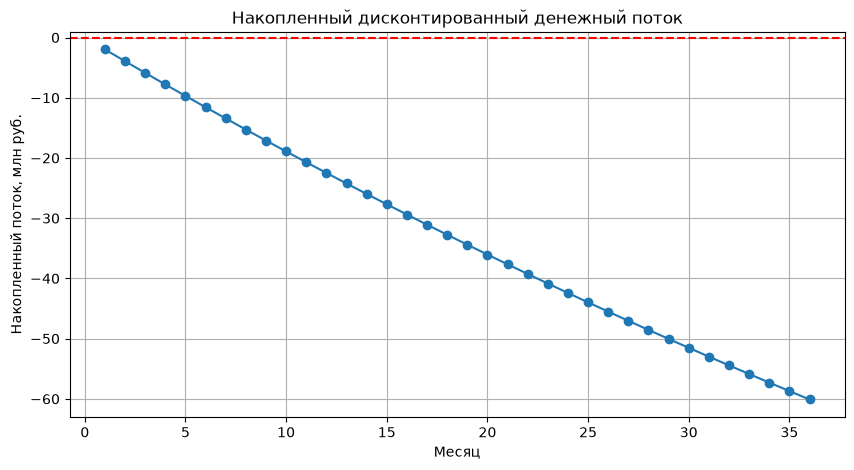

In [30]:
# График накопленного дисконтированного денежного потока.

plt.figure(figsize=(10, 5))

plt.plot(
    npv_df["Месяц"],
    npv_df["Накопленный дисконтированный поток, руб."] / 1_000_000,
    marker="o"
)

plt.axhline(0, color="red", linestyle="--")

plt.title("Накопленный дисконтированный денежный поток")
plt.xlabel("Месяц")
plt.ylabel("Накопленный поток, млн руб.")

plt.grid()
plt.show()

### Интерпретация

NPV проекта составляет примерно −60,1 млн руб.

Накопленный дисконтированный денежный поток остаётся отрицательным на всём горизонте 36 месяцев и не пересекает нулевую линию.

Следовательно, проект не достигает окупаемости в течение трёх лет.

### Анализ чувствительности NPV к темпам роста

Рассмотрим три сценария:

- пессимистичный: рост 2% до критической массы и 10% после;
- базовый: рост 3% до критической массы и 15% после;
- оптимистичный: рост 5% до критической массы и 20% после.

In [31]:
# Расчёт NPV для разных сценариев роста.

scenarios = {
    "Пессимистичный": (0.02, 0.10),
    "Базовый": (0.03, 0.15),
    "Оптимистичный": (0.05, 0.20)
}

scenario_results = []

for scenario_name, growth_rates in scenarios.items():
    growth_before_scenario = growth_rates[0]
    growth_after_scenario = growth_rates[1]

    scenario_users = calculate_users(
        initial_users=N0,
        critical_mass=critical_mass,
        market_size=M,
        growth_before=growth_before_scenario,
        growth_after=growth_after_scenario,
        months=horizon
    )

    scenario_df = pd.DataFrame({
        "Месяц": range(0, horizon + 1),
        "Пользователи": scenario_users
    })

    scenario_df["Новые пользователи"] = (
        scenario_df["Пользователи"].diff().fillna(0)
    )

    scenario_df["Прибыль, руб."] = (
        arpu * scenario_df["Пользователи"]
        - maintenance_cost
        - cac * scenario_df["Новые пользователи"]
    )

    scenario_df["Дисконтированная прибыль, руб."] = (
        scenario_df["Прибыль, руб."]
        / (1 + discount_rate) ** scenario_df["Месяц"]
    )

    scenario_npv = scenario_df.loc[
        scenario_df["Месяц"] > 0,
        "Дисконтированная прибыль, руб."
    ].sum()

    scenario_results.append({
        "Сценарий": scenario_name,
        "Пользователи на 36-м месяце": scenario_df.iloc[-1]["Пользователи"],
        "NPV, руб.": scenario_npv
    })

scenario_results_df = pd.DataFrame(scenario_results)

scenario_results_df.round(2)

,Сценарий,Пользователи на 36-м месяце,"NPV, руб."
0,Пессимистичный,10199.44,-59086830.45
1,Базовый,14491.39,-60099621.18
2,Оптимистичный,28959.08,-63739311.88


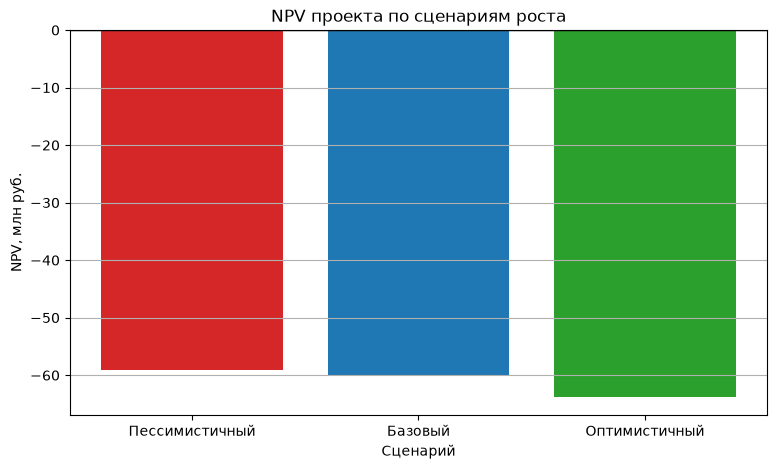

In [32]:
# График NPV по сценариям роста.

plt.figure(figsize=(9, 5))

plt.bar(
    scenario_results_df["Сценарий"],
    scenario_results_df["NPV, руб."] / 1_000_000,
    color=["#d62728", "#1f77b4", "#2ca02c"]
)

plt.axhline(0, color="black", linewidth=1)

plt.title("NPV проекта по сценариям роста")
plt.xlabel("Сценарий")
plt.ylabel("NPV, млн руб.")

plt.grid(axis="y")
plt.show()

### Интерпретация

Во всех трёх сценариях NPV остаётся отрицательным.

В оптимистичном сценарии количество пользователей растёт быстрее, но одновременно увеличиваются затраты на их привлечение. При CAC = 500 руб. ускорение роста не компенсирует дополнительные расходы.

Следовательно, для повышения эффективности необходимо не только увеличивать темп роста, но и снижать CAC или повышать ARPU.

### Минимальный ARPU для безубыточности

Определим минимальное значение ARPU, при котором NPV проекта за 36 месяцев будет равен нулю.

In [33]:
# Расчёт минимального ARPU для безубыточности проекта.

discount_factors = (
    (1 + discount_rate) ** npv_df["Месяц"]
)

discounted_costs = (
    (
        maintenance_cost
        + npv_df["Затраты на привлечение, руб."]
    )
    / discount_factors
).sum()

discounted_users = (
    npv_df["Пользователи"]
    / discount_factors
).sum()

min_arpu = discounted_costs / discounted_users

print(f"Минимальный ARPU для NPV = 0: {min_arpu:,.2f} руб.")

Минимальный ARPU для NPV = 0: 242.55 руб.


### Вывод по части 3

**NPV проекта**

NPV за 36 месяцев составляет примерно −60,1 млн руб. Проект не окупается в течение трёх лет.

**Анализ чувствительности**

Во всех сценариях роста NPV остаётся отрицательным. При высоком CAC ускорение роста приводит к увеличению затрат на привлечение пользователей.

**Минимальный ARPU**

Для безубыточности на горизонте 36 месяцев ARPU должен составлять примерно 242,55 руб. в месяц вместо исходных 15 руб.

Следовательно, для повышения эффективности проекта необходимо одновременно снижать CAC, повышать ARPU и ускорять рост пользовательской базы.

# Часть 4. Стратегические выводы

### Маркетинговые инвестиции для ускорения роста

Определим, какой темп роста необходим, чтобы достичь критической массы на 6 месяцев раньше.

In [34]:
# Расчёт необходимого темпа роста для достижения
# критической массы на 6 месяцев раньше.

import math

base_month = math.ceil(
    math.log(critical_mass / N0)
    / math.log(1 + growth_before)
)

target_month = base_month - 6

required_growth = (
    (critical_mass / N0) ** (1 / target_month)
    - 1
)

print(f"Базовый срок достижения: {base_month} месяцев")
print(f"Целевой срок достижения: {target_month} месяцев")
print(f"Необходимый темп роста: {required_growth:.2%} в месяц")

Базовый срок достижения: 133 месяцев
Целевой срок достижения: 127 месяцев
Необходимый темп роста: 3.13% в месяц


### Дополнительные пользователи и маркетинговые инвестиции

При базовом темпе роста 3% в месяц через 127 месяцев число пользователей будет ниже критической массы.

Рассчитаем, сколько дополнительных пользователей необходимо привлечь и какой объём маркетинговых инвестиций для этого потребуется.

In [35]:
# Расчёт дополнительных пользователей и маркетинговых инвестиций.

users_with_base_growth = (
    N0 * (1 + growth_before) ** target_month
)

additional_users = (
    critical_mass - users_with_base_growth
)

marketing_investment = (
    additional_users * cac
)

print(
    f"Пользователи при росте 3%: "
    f"{users_with_base_growth:,.0f}"
)

print(
    f"Необходимо привлечь дополнительно: "
    f"{additional_users:,.0f} пользователей"
)

print(
    f"Маркетинговые инвестиции: "
    f"{marketing_investment:,.0f} руб."
)

Пользователи при росте 3%: 213,451
Необходимо привлечь дополнительно: 36,549 пользователей
Маркетинговые инвестиции: 18,274,660 руб.


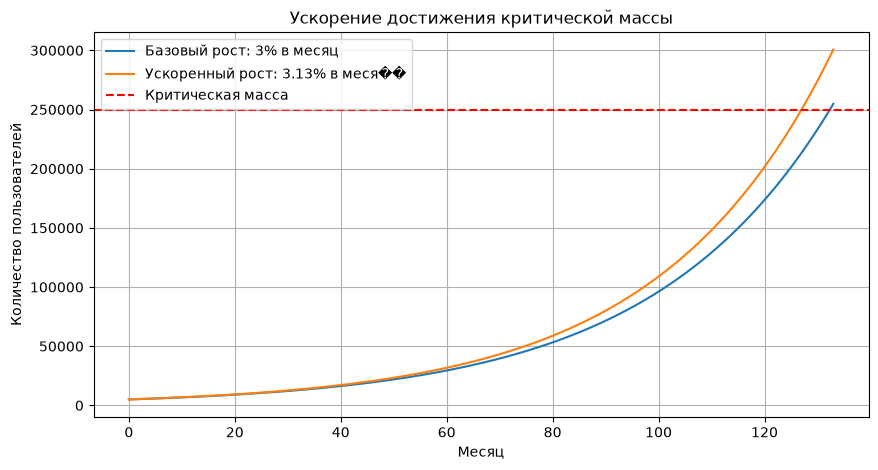

In [36]:
# Сравнение базовой и ускоренной траектории роста.

months_strategy = range(0, base_month + 1)

base_users_strategy = [
    N0 * (1 + growth_before) ** month
    for month in months_strategy
]

accelerated_users_strategy = [
    N0 * (1 + required_growth) ** month
    for month in months_strategy
]

plt.figure(figsize=(10, 5))

plt.plot(
    months_strategy,
    base_users_strategy,
    label="Базовый рост: 3% в месяц"
)

plt.plot(
    months_strategy,
    accelerated_users_strategy,
    label=f"Ускоренный рост: {required_growth:.2%} в меся��"
)

plt.axhline(
    critical_mass,
    color="red",
    linestyle="--",
    label="Критическая масса"
)

plt.title("Ускорение достижения критической массы")
plt.xlabel("Месяц")
plt.ylabel("Количество пользователей")

plt.legend()
plt.grid()
plt.show()

### Интерпретация

Чтобы достичь критической массы на 6 месяцев раньше, необходимо увеличить ежемесячный темп роста с 3% до примерно 3,13%.

Для этого к 127-му месяцу нужно дополнительно привлечь около 36,5 тыс. пользователей.

При исходном CAC = 500 руб. необходимый объём дополнительных маркетинговых инвестиций составляет примерно 18,3 млн руб.

### Рекомендации по стратегии достижения критической массы

1. Снижать CAC через реферальные программы и вирусный маркетинг. Пользователи должны получать стимул приглашать друзей в сеть.

2. Запускать сеть поэтапно: сначала в отдельных районах, вузах, жилых комплексах или сообществах города. Это позволит быстрее сформировать плотную локальную сеть контактов.

3. Привлекать якорных пользователей: городские сообщества, местный бизнес, организаторов мероприятий и популярных авторов контента.

4. Повышать ARPU через рекламу местного бизнеса, платные дополнительные функции и партнёрские программы.

5. Контролировать затраты на поддержку сети и маркетинг. При исходном CAC = 500 руб. ускорение роста требует значительных инвестиций и не гарантирует окупаемость проекта.

### Вывод по части 4

**Маркетинговые инвестиции**

Для достижения критической массы на 6 месяцев раньше необходимо увеличить темп роста с 3% до 3,13% в месяц.

Потребуется дополнительно привлечь около 36,5 тыс. пользователей. При CAC = 500 руб. дополнительные маркетинговые инвестиции составят примерно 18,3 млн руб.

**Стратегические рекомендации**

Основные направления стратегии: снижение CAC через вирусный маркетинг, поэтапный локальный запуск, привлечение якорных пользователей и повышение ARPU.

Главный вывод: ускорение роста без снижения CAC экономически рискованно. Для достижения самоокупаемости компании необходимо одновременно увеличивать пользовательскую базу, снижать стоимость привлечения и повышать доход от пользователя.